# 01: MIND Rank Position EDA

The goal is to understand the impression-level dataset before causal modeling.

Main questions:

- How many displayed items, impressions, users, and news items are in the sample?
- How does click-through rate vary by rank position?
- Is `is_top_3` a reasonable first treatment definition?
- Do top-3 and lower-ranked items differ on observed covariates?

## Project Framing

### What You Will Build

This project builds an end-to-end causal ranking audit for MIND news recommendation impressions. You will define top-3 exposure as the treatment, use click-through as the outcome, audit overlap and observed confounding, estimate adjusted effects, study segment variation, and translate the evidence into experiment-prioritization guidance.

### How To Use This Project

Work through the notebooks in order. This first notebook defines the data, treatment, outcome, and initial descriptive patterns. Later notebooks add propensity weighting, doubly robust estimation, heterogeneous effects, policy simulation, sensitivity analysis, and machine-learning nuisance models. The final report notebook is mainly an artifact builder for figures and snippets.

### Data Source And Scope

The data come from MIND news recommendation impression logs, which include user histories, impression slates, clicked labels, and news metadata. The analysis is observational, so the project emphasizes adjustment, overlap, sensitivity checks, and the need for online validation before making a production ranking claim.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

This is a real observational ranking log, not a randomized ranking experiment. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that are not fully observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook establishes the MIND data structure, rank-position treatment definition, click outcome, and first descriptive checks before any causal estimator is trusted.

<!-- mathematical-setup -->

## Mathematical Setup

The first notebook is descriptive, but it still needs a mathematical baseline. For an impression item \(i\), let \(T_i = 1\) mean the item was shown in a top-rank position and let \(Y_i = 1\) mean the user clicked it. The observed click-through rate in a group is

$$
\widehat{\operatorname{CTR}}(t) = \frac{\sum_{i=1}^n \mathbb{1}(T_i=t)Y_i}{\sum_{i=1}^n \mathbb{1}(T_i=t)}.
$$

The raw top-rank gap is

$$
\widehat{\Delta}_{\text{naive}} = \widehat{\operatorname{CTR}}(1)-\widehat{\operatorname{CTR}}(0).
$$

This is useful as a descriptive starting point, but it is not a causal effect because ranking position is chosen by the platform. A causal claim would require comparing potential outcomes,

$$
\tau = \mathbb{E}\left[Y_i(1)-Y_i(0)\right],
$$

where \(Y_i(1)\) is the click outcome the same item-impression would have had under top placement and \(Y_i(0)\) is the outcome it would have had without top placement. The rest of the project asks how much of the raw gap remains after adjusting for observed selection into top ranks.


#### Setup

This cell imports the libraries used throughout the EDA notebook. `pandas` handles tabular data, `matplotlib` and `seaborn` create plots, and `Path` makes file paths work cleanly from the project root, `notebooks/`, or `notebooks/projects/project_1_ranking/`. The display settings make tables easier to read by showing more columns and formatting floating-point values consistently.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

This cell prepares the notebook environment for MIND ranking EDA and the first top-rank treatment definition. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Locate The Processed Dataset

This cell finds the project root and builds the path to the processed MIND sample. The ancestor search starting from `Path.cwd()` lets the notebook work whether it is launched from the repository root, `notebooks/`, or `notebooks/projects/project_1_ranking/`. `DATA_PATH` should point to the parquet file created by the data-processing script.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
DATA_PATH

PosixPath('/home/apex/Documents/portfolio/data/processed/mind_small_impressions_train_sample.parquet')

The printed paths are a reproducibility checkpoint. Once the notebook can find the input data and output folders, the analysis can run from a clean checkout without manual path edits.


#### Load The Impression-Level Table

This cell reads the processed parquet file into a pandas DataFrame called `df`. Each row represents one displayed item within a recommendation impression, so the table is already in the right shape for rank-position analysis. Showing `df.head()` gives a quick visual check that the expected columns loaded correctly.

In [3]:
df = pd.read_parquet(DATA_PATH)
df.head()

,impression_id,user_id,timestamp,news_id,rank_position,is_top_1,is_top_3,clicked,history_len,candidate_set_size,category,subcategory,title_length,abstract_length,hour,day_of_week,item_exposures,item_clicks,item_ctr,missing_news_metadata
0,1,U13740,2019-11-11 09:05:58,N55689,1,1,1,1,9,2,sports,football_nfl,12,24,9,0,2399,549,0.2288,0
1,1,U13740,2019-11-11 09:05:58,N35729,2,0,1,0,9,2,news,newsus,11,19,9,0,2029,459,0.2262,0
2,2,U91836,2019-11-12 18:11:30,N20678,1,1,1,0,82,11,sports,more_sports,15,13,18,1,874,66,0.0755,0
3,2,U91836,2019-11-12 18:11:30,N39317,2,0,1,0,82,11,news,newspolitics,11,22,18,1,811,65,0.0801,0
4,2,U91836,2019-11-12 18:11:30,N58114,3,0,1,0,82,11,autos,autosnews,11,0,18,1,1054,24,0.0228,0


The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


## Column Guide

Each row in this processed table represents one news item displayed inside one recommendation impression. The columns mean:

- `impression_id`: Unique ID for the page/impression event where a set of news items was shown.
- `user_id`: Anonymous user identifier from MIND.
- `timestamp`: Time when the impression occurred.
- `news_id`: ID of the displayed news item.
- `rank_position`: Position of the item in the displayed list. `1` is the top rank.
- `is_top_1`: Indicator equal to `1` if the item is ranked first.
- `is_top_3`: Indicator equal to `1` if the item is ranked in positions 1 through 3. This is our first simple treatment definition.
- `clicked`: Outcome indicator. `1` means the user clicked the displayed item; `0` means they did not.
- `history_len`: Number of prior clicked news items in the user history before this impression.
- `candidate_set_size`: Number of items shown in the same impression.
- `category`: Broad news category, such as sports, news, finance, or entertainment.
- `subcategory`: More specific category label within `category`.
- `title_length`: Number of words in the item title.
- `abstract_length`: Number of words in the item abstract.
- `hour`: Hour of day extracted from `timestamp`.
- `day_of_week`: Day of week extracted from `timestamp`, where Monday is `0` and Sunday is `6`.
- `item_exposures`: Number of times this `news_id` appears in the processed sample. This is a simple popularity/exposure proxy.
- `item_clicks`: Number of clicks this `news_id` receives in the processed sample.
- `item_ctr`: Sample click-through rate for the item, computed as `item_clicks / item_exposures`.
- `missing_news_metadata`: Indicator equal to `1` if the displayed item did not successfully join to `news.tsv` metadata.


#### Basic Shape

#### Dataset Size Summary

This cell creates a compact high-level summary of the dataset. It counts displayed-item rows, unique impressions, users, and news items, then reports the overall click-through rate and maximum observed rank. This gives us the scale of the analysis before looking at distributions or models.

In [4]:
summary = pd.Series(
    {
        "rows_displayed_items": len(df),
        "impressions": df["impression_id"].nunique(),
        "users": df["user_id"].nunique(),
        "news_items": df["news_id"].nunique(),
        "overall_ctr": df["clicked"].mean(),
        "max_rank_position": df["rank_position"].max(),
    }
)
summary

rows_displayed_items   737762.0000
impressions             20000.0000
users                   15427.0000
news_items              12349.0000
overall_ctr                 0.0405
max_rank_position         294.0000
dtype: float64

The size summary tells us the scale of the analysis population and whether the sample is large enough for ranking-position comparisons. This gives context for the more detailed distribution and treatment checks that follow.


#### Column Types

This cell displays the data type of each column. This matters because modeling and plotting depend on whether columns are numeric, categorical, datetime, or integer indicators. It also helps catch parsing mistakes early, such as timestamps accidentally being loaded as plain strings.

In [5]:
df.dtypes

impression_id                     int64
user_id                             str
timestamp                datetime64[us]
news_id                             str
rank_position                     int16
is_top_1                           int8
is_top_3                           int8
clicked                            int8
history_len                       int64
candidate_set_size                int32
category                            str
subcategory                         str
title_length                      int32
abstract_length                   int32
hour                               int8
day_of_week                        int8
item_exposures                    int64
item_clicks                       int64
item_ctr                        float64
missing_news_metadata              int8
dtype: object

This output clarifies the structure of the data before modeling begins. Knowing which columns are numeric, categorical, treatment-related, or outcome-related helps prevent accidental leakage and keeps the causal design readable.


#### Missingness Check

This cell computes the missing-value rate for every column. `df.isna()` marks missing entries, `.mean()` turns those true/false indicators into a fraction missing per column, and the final filter shows only columns with any missing values. If the output is empty, the processed table has no missing values.


In [6]:
missing = df.isna().mean().sort_values(ascending=False).rename("missing_rate")
missing[missing > 0]

Series([], Name: missing_rate, dtype: float64)

The missingness output shows whether key treatment, outcome, and covariate fields are complete enough for causal analysis. Low missingness means later estimates are less likely to be driven by silent row drops or inconsistent feature availability.


### Outcome and Rank Distributions

#### Key Numeric Distributions

This cell summarizes the main numeric columns used in the first analysis. `rank_position` describes where items appear, `clicked` is the outcome, `history_len` describes user history size, `candidate_set_size` describes the slate size, and `item_ctr` is a simple item-level engagement proxy. The percentiles help us spot skew, outliers, and unusually large values.

In [7]:
df[["rank_position", "clicked", "history_len", "candidate_set_size", "item_ctr"]].describe()

,rank_position,clicked,history_len,candidate_set_size,item_ctr
count,737762.0000,737762.0000,737762.0000,737762.0000,737762.0000
mean,38.8271,0.0405,35.4340,76.6542,0.0405
std,37.6288,0.1972,41.6360,52.7167,0.0465
min,1.0000,0.0000,0.0000,2.0000,0.0000
25%,11.0000,0.0000,9.0000,36.0000,0.0153
50%,27.0000,0.0000,21.0000,66.0000,0.0289
75%,55.0000,0.0000,46.0000,108.0000,0.0499
max,294.0000,1.0000,558.0000,294.0000,1.0000


The distribution summary shows the range and skew of the main ranking and engagement variables. These summaries help identify whether transformations, bins, or robust diagnostics are needed before modeling.


#### Visualize Slate And Rank Distributions

This cell plots two histograms. The first shows how many items are displayed per impression, and the second shows the distribution of rank positions in the processed sample. These plots help us understand whether most impressions are short lists, long lists, or a mix of both.

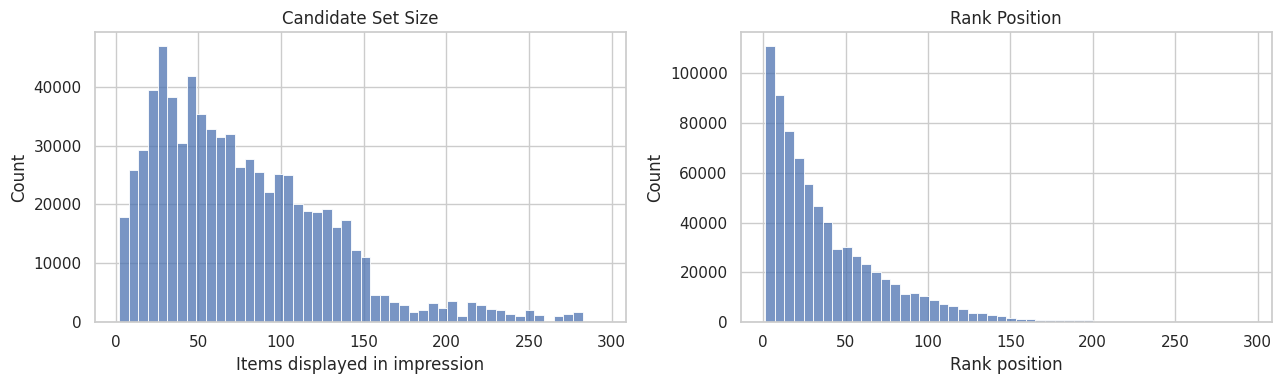

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["candidate_set_size"], bins=50, ax=axes[0])
axes[0].set_title("Candidate Set Size")
axes[0].set_xlabel("Items displayed in impression")

sns.histplot(df["rank_position"], bins=50, ax=axes[1])
axes[1].set_title("Rank Position")
axes[1].set_xlabel("Rank position")

plt.tight_layout()

The plots show how impressions are distributed across ranks and candidate sets. This matters because rank position is both the treatment source and a strong proxy for recommendation-system selection pressure.


### Naive CTR by Rank

This is not causal yet. It mixes true position effects with relevance, popularity, and ranking policy selection.

#### CTR By Exact Rank

This cell summarizes click behavior separately for each displayed rank position. We group all displayed items by `rank_position`, then compute three quantities:

- `clicks`: total number of clicked items at that rank. Since `clicked` is `1` for a click and `0` otherwise, summing it counts clicks.
- `impressions`: total number of displayed items observed at that rank. This is the denominator for CTR.
- `ctr`: click-through rate at that rank, computed as the mean of `clicked`, or `clicks / impressions`.

The output shows the first 15 rank positions so we can quickly inspect whether higher positions receive more clicks. This is a descriptive baseline, not a causal estimate, because high-ranked items may also be more relevant, more popular, or chosen by the ranking system for reasons correlated with clicks.


In [9]:
ctr_by_rank = (
    df.groupby("rank_position")
    .agg(clicks=("clicked", "sum"), impressions=("clicked", "size"), ctr=("clicked", "mean"))
    .reset_index()
)
ctr_by_rank.head(15)

,rank_position,clicks,impressions,ctr
0,1,2229,20000,0.1114
1,2,2201,20000,0.1100
2,3,1528,18646,0.0819
3,4,1302,18164,0.0717
4,5,1100,17257,0.0637
5,6,1056,16914,0.0624
6,7,976,16513,0.0591
7,8,850,15671,0.0542
8,9,792,15420,0.0514
9,10,752,15048,0.0500


The rank-level CTR table shows how click probability changes as an item moves down the slate. This descriptive pattern motivates using top-rank exposure as the first treatment definition, while remembering that the comparison is still confounded by ranking logic.


#### Plot Naive CTR For The First 50 Ranks

This cell turns the exact-rank CTR table into a line plot. It restricts the display to ranks 1 through 50 because those positions are easiest to interpret visually, and farther ranks can make the chart too compressed. The goal is to see the raw shape of click decay as rank position gets lower.

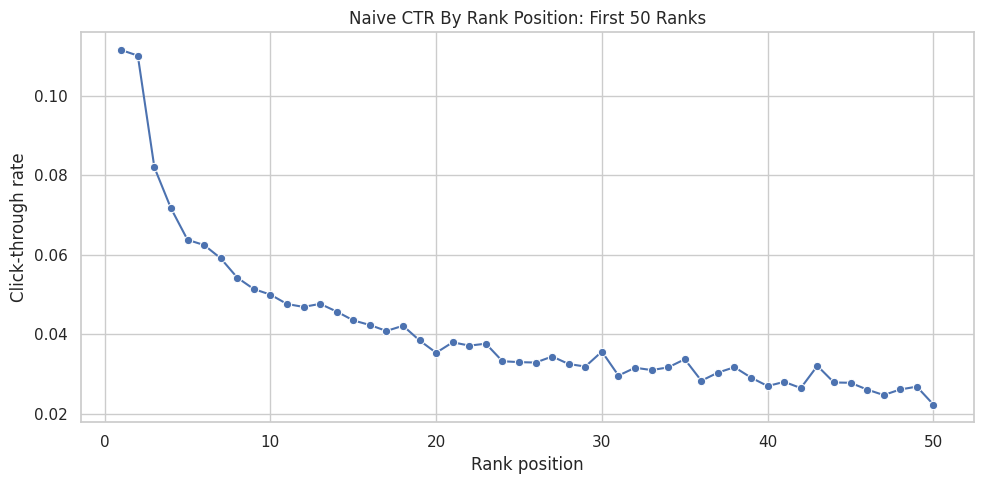

In [10]:
plot_df = ctr_by_rank.query("rank_position <= 50")

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x="rank_position", y="ctr", marker="o")
plt.title("Naive CTR By Rank Position: First 50 Ranks")
plt.xlabel("Rank position")
plt.ylabel("Click-through rate")
plt.tight_layout()

The plot makes the raw position bias visually obvious: higher ranks tend to receive different click rates than lower ranks. The next step groups ranks into interpretable buckets so the treatment definition is easier to explain.


#### CTR By Rank Bucket

The previous table computed CTR for every exact rank position. That is useful, but exact ranks can get noisy, especially farther down the recommendation list where there may be fewer impressions or very low click rates. This cell groups nearby rank positions into larger buckets so the pattern is easier to read.

First, we define the bucket boundaries:

- `0` to `1` becomes bucket `"1"`, meaning the top-ranked item.
- `1` to `3` becomes bucket `"2-3"`, meaning ranks 2 and 3.
- `3` to `10` becomes bucket `"4-10"`.
- `10` to `25` becomes bucket `"11-25"`.
- `25` to `50` becomes bucket `"26-50"`.
- `50` to the maximum observed rank becomes bucket `"51+"`.

`pd.cut(...)` takes each item's numeric `rank_position` and assigns it to one of those labeled intervals. For example, an item at rank 7 gets `rank_bucket = "4-10"`, while an item at rank 30 gets `rank_bucket = "26-50"`. `include_lowest=True` makes sure the lowest rank boundary is included, and `duplicates="drop"` protects the code if the maximum rank makes any bin edges duplicate.

Then we group by `rank_bucket` and compute the same descriptive metrics as before, including `clicks`, `impressions`, and `ctr`. This gives a smoother descriptive view of how engagement changes from highly visible positions to lower positions. The result is still descriptive because items in higher buckets may differ systematically from items in lower buckets.

In [11]:
rank_bins = [0, 1, 3, 10, 25, 50, df["rank_position"].max()]
rank_labels = ["1", "2-3", "4-10", "11-25", "26-50", "51+"]

df = df.assign(
    rank_bucket=pd.cut(
        df["rank_position"],
        bins=rank_bins,
        labels=rank_labels,
        include_lowest=True,
        duplicates="drop",
    )
)

ctr_by_bucket = (
    df.groupby("rank_bucket", observed=True)
    .agg(clicks=("clicked", "sum"), impressions=("clicked", "size"), ctr=("clicked", "mean"))
    .reset_index()
)
ctr_by_bucket

,rank_bucket,clicks,impressions,ctr
0,1,2229,20000,0.1114
1,2-3,3729,38646,0.0965
2,4-10,6828,114987,0.0594
3,11-25,7455,181168,0.0411
4,26-50,5340,177476,0.0301
5,51+,4313,205485,0.0210


The bucketed CTR table turns many individual ranks into readable exposure groups. This is useful because the causal question is about a product-relevant intervention, not about memorizing every exact rank position.


#### Plot CTR By Rank Bucket

This cell visualizes the bucket-level CTR table as a bar chart. The chart makes the rank-position pattern easier to communicate than the raw table, especially for a final report or product memo. Each bar shows the average click rate for a broader visibility group.

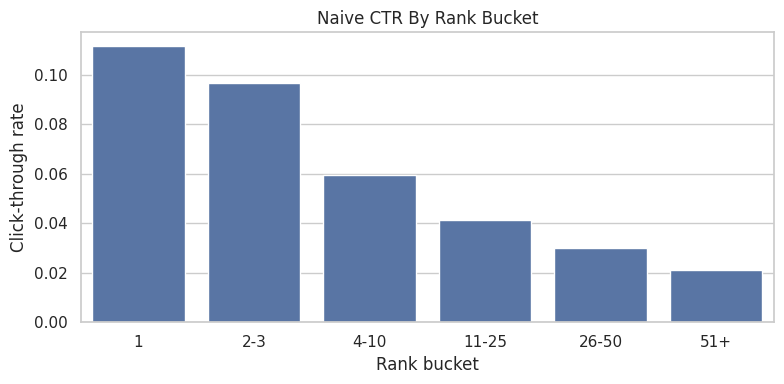

In [12]:
plt.figure(figsize=(8, 4))
sns.barplot(data=ctr_by_bucket, x="rank_bucket", y="ctr")
plt.title("Naive CTR By Rank Bucket")
plt.xlabel("Rank bucket")
plt.ylabel("Click-through rate")
plt.tight_layout()

The bucketed plot shows the same position-bias pattern in a cleaner product format. It supports the top-rank versus lower-rank treatment contrast used in the next cells.


### First Treatment Definition

The causal project needs a clear treatment, control group, and outcome. In this first pass, we use a simple binary treatment based on rank position:

- **Treatment group**: displayed items where `is_top_3 = 1`, meaning the item appeared in rank positions 1, 2, or 3.
- **Control group**: displayed items where `is_top_3 = 0`, meaning the item appeared below position 3.
- **Outcome**: `clicked`, where `1` means the user clicked the item and `0` means they did not.

The purpose of this section is to create a simple baseline contrast: items near the top of the ranking versus items lower in the ranking. This is easier to reason about than comparing every exact rank position at once, and it sets up the next notebook where we will estimate a propensity model for `P(is_top_3 = 1 | X)`.

The table below computes click-through rate for both groups. Then we calculate two versions of **lift**:

- **Absolute lift**: the difference in CTR between top-3 items and lower-ranked items. For example, if top-3 CTR is `0.09` and lower-ranked CTR is `0.03`, the absolute lift is `0.06`, or 6 percentage points.
- **Relative lift**: the proportional increase in CTR for top-3 items compared with lower-ranked items. Using the same example, `(0.09 / 0.03) - 1 = 2.0`, or 200% relative lift.

This lift is **naive descriptive lift**, not a causal effect yet. Top-3 items are not randomly assigned. The ranking system probably places more relevant or popular items near the top, so the raw CTR gap combines position effects with selection effects. The goal here is to measure the raw gap first, then later adjust for observed confounding with IPW and doubly robust estimation.

#### Summarize Treatment And Control Outcomes

This cell compares the two groups created by the treatment definition. Rows with `is_top_3 = 1` are labeled `top_3`, and rows with `is_top_3 = 0` are labeled `rank_4_plus`. For each group, the table reports the number of rows, total clicks, and click-through rate.

In [13]:
treatment_summary = (
    df.groupby("is_top_3")
    .agg(rows=("clicked", "size"), clicks=("clicked", "sum"), ctr=("clicked", "mean"))
    .rename(index={0: "rank_4_plus", 1: "top_3"})
)
treatment_summary

,rows,clicks,ctr
is_top_3,,,
rank_4_plus,679116,23936,0.0352
top_3,58646,5958,0.1016


The treatment-control summary gives the first naive comparison between exposed and comparison rows. This is a useful descriptive baseline, but it should not be interpreted as causal until confounding and selection are addressed.


#### Compute Naive Lift

This cell computes the raw difference between top-3 CTR and lower-ranked CTR. `naive_lift` is the absolute difference in click probability, while `relative_lift` expresses that difference as a percentage increase over the lower-ranked baseline. This is useful as a descriptive benchmark, but it is not adjusted for confounding.

In [14]:
naive_lift = treatment_summary.loc["top_3", "ctr"] - treatment_summary.loc["rank_4_plus", "ctr"]
relative_lift = treatment_summary.loc["top_3", "ctr"] / treatment_summary.loc["rank_4_plus", "ctr"] - 1
print(f"Naive absolute lift: {naive_lift:.4f}")
print(f"Naive relative lift: {relative_lift:.1%}")

Naive absolute lift: 0.0663
Naive relative lift: 188.2%


The naive lift quantifies the raw click-rate gap between treatment and control groups. It is the starting point for the project: later notebooks ask how much of this apparent lift remains after adjustment.


### Confounding Checks

The naive top-3 lift compares click rates for items ranked in positions 1-3 against items ranked lower. That comparison is useful as a first descriptive baseline, but it is not automatically causal because ranking position is not randomly assigned.

A **confounder** is a variable that affects both the treatment and the outcome. In this project:

- The **treatment** is whether an item appears in the top 3: `is_top_3`.
- The **outcome** is whether the item is clicked: `clicked`.
- A potential **confounder** is any observed feature that may influence both where the item is ranked and whether it gets clicked.

For example, a very popular article may be more likely to appear near the top and also more likely to get clicked even if its position had not changed. If we do not adjust for that, we may wrongly attribute the popularity effect to rank position.

The purpose of the following cells is to check whether the treated group (`is_top_3 = 1`) and control group (`is_top_3 = 0`) look different before causal adjustment.

First, we compare numeric covariates:

- `history_len`: whether users seeing top-3 items have different prior activity.
- `candidate_set_size`: whether top-3 rows come from impressions with different slate sizes.
- `title_length` and `abstract_length`: simple content-text proxies.
- `item_exposures`, `item_clicks`, and `item_ctr`: item popularity and historical engagement proxies.
- `hour` and `day_of_week`: timing/context features.

The numeric balance table reports the mean of each feature in the lower-ranked group and the top-3 group, then computes:

- `diff_top3_minus_lower`: top-3 mean minus lower-ranked mean.
- `relative_diff`: that difference divided by the lower-ranked mean.

Large differences suggest that top-3 and lower-ranked items are not directly comparable without adjustment.

Next, we compare categorical covariates using `category`. The category table shows each category's share within the lower-ranked group versus the top-3 group. If some categories are much more common in the top-3 group, category is a likely confounder and should be included in the propensity model.

Finally, the bar plot visualizes the category mix for the most common categories. This makes it easier to see whether the ranking system places certain content categories near the top more often than others.

These checks do not solve confounding by themselves. They tell us what imbalance exists so the next step, propensity modeling and IPW, can adjust for observed differences between top-3 and lower-ranked items.

#### Numeric Covariate Balance

This cell compares average numeric feature values between lower-ranked rows and top-3 rows. The goal is to see whether the two groups differ on observed covariates before any causal adjustment. Large differences imply that naive lift is mixing rank-position effects with differences in user context, item characteristics, or timing.

In [15]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "item_exposures",
    "item_clicks",
    "item_ctr",
    "hour",
    "day_of_week",
]

balance = df.groupby("is_top_3")[numeric_features].mean().T
balance.columns = ["rank_4_plus", "top_3"]
balance["diff_top3_minus_lower"] = balance["top_3"] - balance["rank_4_plus"]
balance["relative_diff"] = balance["diff_top3_minus_lower"] / balance["rank_4_plus"].replace(0, pd.NA)
balance.sort_values("relative_diff", key=lambda s: s.abs(), ascending=False)

,rank_4_plus,top_3,diff_top3_minus_lower,relative_diff
item_clicks,30.8286,62.4235,31.5950,1.0249
candidate_set_size,80.0187,37.6936,-42.3251,-0.5289
item_ctr,0.0390,0.0577,0.0186,0.4769
item_exposures,619.2887,840.5458,221.2571,0.3573
history_len,35.6583,32.8360,-2.8224,-0.0792
day_of_week,2.2356,2.1808,-0.0548,-0.0245
title_length,10.9443,11.0837,0.1393,0.0127
hour,10.7980,10.8809,0.0830,0.0077
abstract_length,25.3329,25.2988,-0.0340,-0.0013


The numeric balance table checks whether treated and control impressions differ before adjustment. Any imbalance here is evidence that raw CTR differences mix ranking exposure effects with the recommender's selection behavior.


#### Category Balance

This cell checks whether the content category mix differs between top-3 and lower-ranked rows. It uses a normalized crosstab so each column sums to 1, then computes the difference in category share between the two groups. Large category differences suggest that category should be included in later adjustment models.

In [16]:
category_balance = (
    pd.crosstab(df["category"], df["is_top_3"], normalize="columns")
    .rename(columns={0: "rank_4_plus", 1: "top_3"})
)
category_balance["diff_top3_minus_lower"] = category_balance["top_3"] - category_balance["rank_4_plus"]
category_balance.sort_values("diff_top3_minus_lower", key=lambda s: s.abs(), ascending=False).head(15)

is_top_3,rank_4_plus,top_3,diff_top3_minus_lower
category,,,
news,0.2678,0.3091,0.0413
foodanddrink,0.0653,0.0419,-0.0234
health,0.0532,0.0368,-0.0164
travel,0.0556,0.0393,-0.0163
autos,0.0482,0.0331,-0.0151
music,0.0448,0.0594,0.0146
sports,0.0997,0.1138,0.0141
weather,0.0142,0.0245,0.0103
lifestyle,0.1132,0.1048,-0.0084


The category balance table checks whether different content types are overrepresented in top positions. Category imbalance matters because content preferences can affect clicks independently of rank exposure. This result connects directly to identification because remaining imbalance marks places where observed confounding may still be shaping the estimated effect.


#### Plot Category Mix Differences

This cell visualizes the category-balance table for the most common categories. The grouped bar chart makes it easier to see whether certain categories appear disproportionately in the top-3 group. This is a visual confounding diagnostic, not a causal estimate.

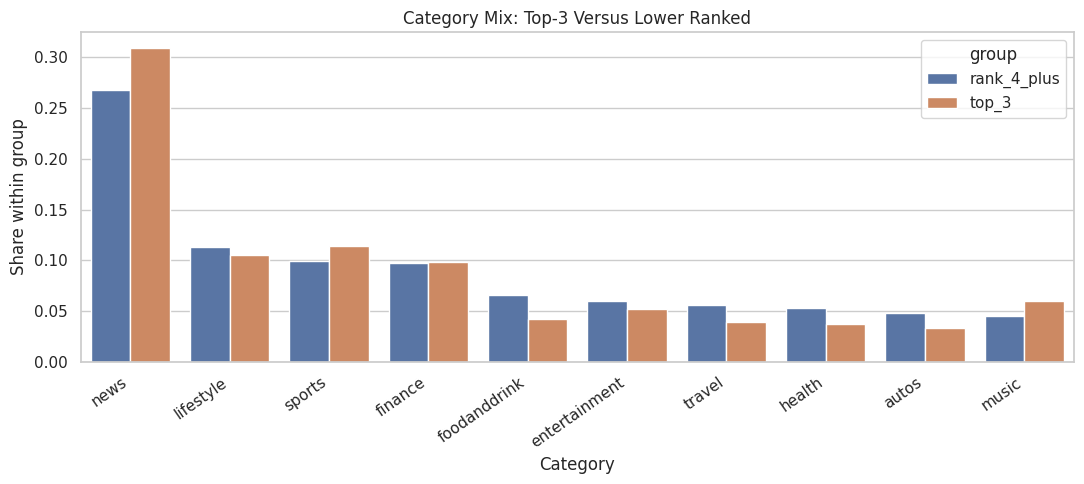

In [17]:
top_categories = df["category"].value_counts().head(10).index
plot_df = category_balance.loc[top_categories, ["rank_4_plus", "top_3"]].reset_index()
plot_df = plot_df.melt(id_vars="category", var_name="group", value_name="share")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="category", y="share", hue="group")
plt.title("Category Mix: Top-3 Versus Lower Ranked")
plt.xlabel("Category")
plt.ylabel("Share within group")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

The plot makes content-mix imbalance easier to scan. If top-ranked and lower-ranked impressions contain different categories, later models should adjust for category and subcategory features.


#### Notes For Next Step

The next notebook estimates `P(is_top_3 | X)` and inspects overlap.

Candidate covariates:

- `history_len`
- `candidate_set_size`
- `category`, `subcategory`
- `title_length`, `abstract_length`
- `hour`, `day_of_week`
- item popularity proxies such as `item_exposures` and `item_ctr`

The naive top-3 lift is a baseline descriptive contrast. The causal analysis begins once the project studies whether top-ranked and lower-ranked impressions are comparable after conditioning on observed features.